In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ExoplanetArchiveAllClean.csv")
df.head()

/tmp/ipykernel_1248954/3107483945.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ExoplanetArchiveAllClean.csv")


,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,...,9/19/2023,2023-12,9/19/2023,2,1,2,0,0,0,0
1,2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,7/23/2014,2011-08,7/23/2014,2,1,2,0,0,0,0
2,3,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,5/14/2014,2008-01,5/14/2014,2,1,2,0,0,0,0
3,4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,4/25/2018,2011-08,7/23/2014,0,1,1,0,0,0,0
4,5,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,4/25/2018,2009-10,5/14/2014,0,1,1,0,0,0,0


Note: default_flag is 1 for the accepted values of a planet and 0 for all other values of a planet, filter by default_flag==1 to get one of each planet

In [3]:
# Filter to have one of each planet
#df = df.drop(df[df.default_flag == 1].index)

In [4]:
len(df["pl_rade"].dropna()) / len(df["pl_rade"])

0.6899236487844083

In [5]:
# GET TARGET (RADIUS)
df = df.dropna(subset=['pl_rade'])

y = np.log10(df["pl_rade"])
df = df.drop(["pl_rade", "pl_radj"], axis=1)

In [6]:
# PREPROCESS MASS DATA

mass_column_names = ['pl_masse',
 'pl_masseerr1',
 'pl_masseerr2',
 'pl_masselim',
 'pl_massj',
 'pl_massjerr1',
 'pl_massjerr2',
 'pl_massjlim',
 'pl_msinie',
 'pl_msinieerr1',
 'pl_msinieerr2',
 'pl_msinielim',
 'pl_msinij',
 'pl_msinijerr1',
 'pl_msinijerr2',
 'pl_msinijlim',
 'pl_cmasse',
 'pl_cmasseerr1',
 'pl_cmasseerr2',
 'pl_cmasselim',
 'pl_cmassj',
 'pl_cmassjerr1',
 'pl_cmassjerr2',
 'pl_cmassjlim',
 'pl_bmasse',
 'pl_bmasseerr1',
 'pl_bmasseerr2',
 'pl_bmasselim',
 'pl_bmassj',
 'pl_bmassjerr1',
 'pl_bmassjerr2',
 'pl_bmassjlim',
 'pl_bmassprov',
 'pl_dens']

mass_columns = {"Mass":"pl_masse", "Msini":"pl_msinie", "Msin(i)/sin(i)":"pl_cmasse"}

mass = []
mass_error_width = []
mass_type = []

for i, row in df.iterrows():
    t = row["pl_bmassprov"]
    if t in mass_columns:
        m = row[mass_columns[t]]
        merr1 = row[mass_columns[t] + "err1"]
        merr2 = row[mass_columns[t] + "err2"]
        
        mass.append(m)
        mass_type.append(t)
        mass_error_width.append(abs(merr1)+abs(merr2))
    else:
        mass.append(np.NaN)
        mass_type.append(np.NaN)
        mass_error_width.append(np.NaN)

df["pl_mass"] = mass
df["pl_mass_type"] = mass_type

df = df.drop(mass_column_names, axis=1)

In [7]:
to_drop = ['default_flag', "pl_letter", "sy_mnum"]
for s in df.columns:
    if s.endswith("err1") or s.endswith("err2") or s.endswith("lim") or s.endswith("name") or s.endswith("id"):
        to_drop.append(s)
    if s in ['rv_flag', 'pul_flag', 'ptv_flag', 'tran_flag','ast_flag','obm_flag','micro_flag','etv_flag','ima_flag','dkin_flag']: # duplicates from discovery method
        to_drop.append(s)
X = df.drop(to_drop, axis=1)

In [14]:
to_drop

['default_flag',
 'pl_letter',
 'sy_mnum',
 'rowid',
 'pl_name',
 'hostname',
 'hd_name',
 'hip_name',
 'tic_id',
 'gaia_dr2_id',
 'gaia_dr3_id',
 'disc_refname',
 'rv_flag',
 'pul_flag',
 'ptv_flag',
 'tran_flag',
 'ast_flag',
 'obm_flag',
 'micro_flag',
 'etv_flag',
 'ima_flag',
 'dkin_flag',
 'pl_refname',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_denserr1',
 'pl_denserr2',
 'pl_denslim',
 'pl_orbeccenerr1',
 'pl_orbeccenerr2',
 'pl_orbeccenlim',
 'pl_insolerr1',
 'pl_insolerr2',
 'pl_insollim',
 'pl_eqterr1',
 'pl_eqterr2',
 'pl_eqtlim',
 'pl_orbinclerr1',
 'pl_orbinclerr2',
 'pl_orbincllim',
 'pl_tranmid',
 'pl_tranmiderr1',
 'pl_tranmiderr2',
 'pl_tranmidlim',
 'pl_impparerr1',
 'pl_impparerr2',
 'pl_impparlim',
 'pl_trandeperr1',
 'pl_trandeperr2',
 'pl_trandeplim',
 'pl_trandurerr1',
 'pl_trandurerr2',
 'pl_trandur

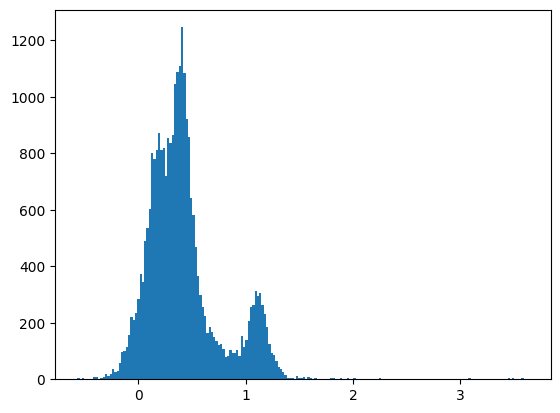

In [8]:
plt.hist(y, bins="auto")
plt.show()

In [9]:
len(y)

27470

In [10]:
b = y.mean()
MSE = ((y - b)**2).mean()
print("b =", b)
print("MSE =", MSE)

b = 0.4199218519093624
MSE = 0.11838178972423995


In [13]:
10**b

2.6297947371397634

In [12]:
list(X.columns)

['sy_snum',
 'sy_pnum',
 'cb_flag',
 'discoverymethod',
 'disc_year',
 'disc_pubdate',
 'disc_locale',
 'disc_facility',
 'disc_telescope',
 'disc_instrument',
 'soltype',
 'pl_controv_flag',
 'pl_orbper',
 'pl_orbsmax',
 'pl_orbeccen',
 'pl_insol',
 'pl_eqt',
 'pl_orbincl',
 'pl_tsystemref',
 'ttv_flag',
 'pl_imppar',
 'pl_trandep',
 'pl_trandur',
 'pl_ratdor',
 'pl_ratror',
 'pl_occdep',
 'pl_orbtper',
 'pl_orblper',
 'pl_rvamp',
 'pl_projobliq',
 'pl_trueobliq',
 'st_spectype',
 'st_teff',
 'st_rad',
 'st_mass',
 'st_met',
 'st_metratio',
 'st_lum',
 'st_logg',
 'st_age',
 'st_dens',
 'st_vsin',
 'st_rotp',
 'st_radv',
 'rastr',
 'ra',
 'decstr',
 'dec',
 'glat',
 'glon',
 'elat',
 'elon',
 'sy_pm',
 'sy_pmra',
 'sy_pmdec',
 'sy_dist',
 'sy_plx',
 'sy_bmag',
 'sy_vmag',
 'sy_jmag',
 'sy_hmag',
 'sy_kmag',
 'sy_umag',
 'sy_gmag',
 'sy_rmag',
 'sy_imag',
 'sy_zmag',
 'sy_w1mag',
 'sy_w2mag',
 'sy_w3mag',
 'sy_w4mag',
 'sy_gaiamag',
 'sy_icmag',
 'sy_tmag',
 'sy_kepmag',
 'rowupdate',


In [11]:
# X_number = X.select_dtypes(include='number')
# X_categorical = X.select_dtypes(exclude='number')
# X_number.corr()